In [1]:
import tifffile
import torch
import mlflow
import os
print(torch.__version__)

2.8.0+cu128


In [2]:
from dotenv import load_dotenv
# put your MLflow keys here :
# MLFLOW_TRACKING_URI='https://mlflow-staging.computing.als.lbl.gov'
# MLFLOW_TRACKING_TOKEN = '...'

load_dotenv()

True

In [3]:
MODEL_NAME="f650c5ac-fbba-4069-b6de-b51d242e1ad8/1"

model = mlflow.pytorch.load_model(f"models:/{MODEL_NAME}", map_location=torch.device("cpu"))

#model = mlflow.pytorch.load_model("models:/f650c5ac-fbba-4069-b6de-b51d242e1ad8/1", map_location=torch.device("cpu"))
model.__dict__["image_shape"]

/nsls2/users/skarakuzu1/test_synaps/test_mlflow/.pixi/envs/default/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/02/18 09:58:40 WARNING mlflow.pytorch: Stored model version '2.2.2+cu121' does not match installed PyTorch version '2.8.0+cu128'


(64, 64)

(100, 100, 1)


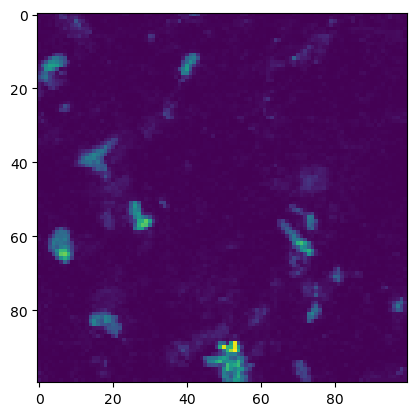

In [4]:
import matplotlib.pyplot as plt
import numpy as np

image_array = tifffile.imread('scan_368343_Ca.tiff')
image_array = image_array[..., None]
print(image_array.shape)

plt.imshow(image_array[:,:,0])


In [5]:
from qlty.qlty2D import NCYXQuilt

image_array = image_array[np.newaxis,]
print(image_array.shape)

image_tensor = torch.from_numpy(image_array).float().permute(0, 3, 1, 2)  # (1, 3, 100, 100), first params is batch size and second param is RGB channels

# define quilt — patch size 32x32, step 16 (50% overlap), border 4px
quilt = NCYXQuilt(
    Y=100,
    X=100,
    window=(64, 64),
    step=(16, 16),
    border=(4, 4),
    border_weight=0.1
)

# split into overlapping patches → (M, 3, 32, 32)
patches = quilt.unstitch(image_tensor)
print(f"Patches shape: {patches.shape}")



(1, 100, 100, 1)
Patches shape: torch.Size([16, 1, 64, 64])


In [6]:
model.eval()

with torch.no_grad():
    output_patches = model(patches)

reconstructed, weights = quilt.stitch(output_patches)
print(f"Reconstructed shape: {reconstructed.shape}")

Reconstructed shape: torch.Size([1, 2, 100, 100])


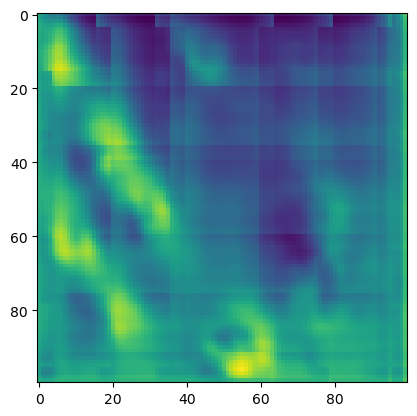

In [7]:
plt.imshow(reconstructed[0,1,:,:])